# Here in this section we are going to work with the Exploratory Data Analysis and futher anaysis on the overall data structure.

In [1]:
# Importing all the libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_pickle(r'C:\Users\acer\Desktop\Programs\Projects_for _data_science\Fraud_Detection_Model\data\02_intermediate\train.pkl')

In [3]:
test = pd.read_pickle(r'C:\Users\acer\Desktop\Programs\Projects_for _data_science\Fraud_Detection_Model\data\02_intermediate\test.pkl')

# Exploratory Data Analysis — Fraud Detection

## Objective

The purpose of this notebook is to understand the behavioural structure of
the IEEE-CIS fraud detection dataset and identify patterns that may help
distinguish fraudulent transactions from legitimate transactions.

This analysis focuses on:

- fraud prevalence
- transaction behaviour
- transaction amount
- temporal behaviour
- categorical behaviour
- identity and device information
- missingness patterns
- relationships between variables and fraud

The objective is not to select a final model.

Instead, EDA should help us form testable hypotheses that can later guide
feature engineering and modelling.

# Step1: **Perfroming Exploratory Data Analysis**

In [4]:
# training data:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [5]:
# overview of the dataframe:

train.info()


<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 1.9 GB


In [6]:
# Checking for the null values:
train.isnull().sum()

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
id_36             449555
id_37             449555
id_38             449555
DeviceType        449730
DeviceInfo        471874
Length: 434, dtype: int64

In [7]:
# Considering the train and test data split:
train

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Fraud Prevalence

Before looking at any individual feature, we need to know how rare fraud
actually is. This single number shapes almost every decision later:
which metrics are meaningful (`19_MODEL_EVALUATION`), whether to use class
weighting or resampling (`18_CLASS_IMBALANCE`), and how much signal we can
realistically expect any one feature to carry on its own.


In [8]:
fraud_counts = train["isFraud"].value_counts()
fraud_rate = train["isFraud"].mean()

print("Class counts:")
print(fraud_counts)
print(f"\nFraud rate: {fraud_rate:.4%}")
print(f"Imbalance ratio (legit : fraud): {fraud_counts[0] / fraud_counts[1]:.1f} : 1")


Class counts:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.4990%
Imbalance ratio (legit : fraud): 27.6 : 1


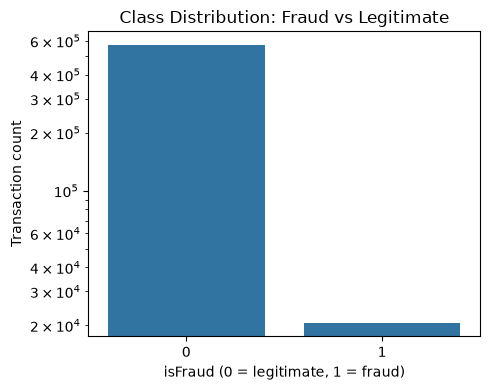

In [9]:
plt.figure(figsize=(5, 4))
sns.countplot(x="isFraud", data=train)
plt.title("Class Distribution: Fraud vs Legitimate")
plt.xlabel("isFraud (0 = legitimate, 1 = fraud)")
plt.ylabel("Transaction count")
plt.yscale("log")
plt.tight_layout()
plt.show()


**Hypothesis to carry forward:** with fraud this rare, accuracy will be a
meaningless metric, and both the modelling approach and the evaluation
metric need to explicitly account for the imbalance.


## 2. Transaction Behaviour

A general look at the shape and volume of the dataset — how many
transactions, how many unique entities, and how transaction frequency is
distributed across accounts. This gives a baseline sense of "normal" volume
before we look for deviations from it (see `09_NORMAL_VS_ABNORMAL_BEHAVIOR`).


In [10]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

if "card1" in train.columns:
    txns_per_card = train.groupby("card1").size()
    print("\nUnique card1 values:", train["card1"].nunique())
    print("\nTransactions per card1 — distribution:")
    print(txns_per_card.describe())


Train shape: (590540, 434)
Test shape: (506691, 433)

Unique card1 values: 13553

Transactions per card1 — distribution:
count    13553.000000
mean        43.572641
std        329.084462
min          1.000000
25%          1.000000
50%          4.000000
75%         14.000000
max      14932.000000
dtype: float64


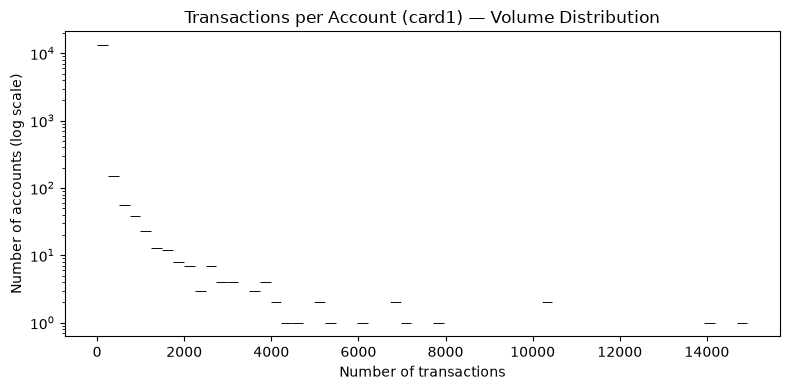

In [11]:
if "card1" in train.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(txns_per_card, bins=60, log_scale=(False, True))
    plt.title("Transactions per Account (card1) — Volume Distribution")
    plt.xlabel("Number of transactions")
    plt.ylabel("Number of accounts (log scale)")
    plt.tight_layout()
    plt.show()


**Hypothesis to carry forward:** most accounts transact only a handful of
times, so behaviour-based features for very low-volume accounts may need a
fallback population-level baseline instead of a self-baseline (too little
history to compare against).


## 3. Transaction Amount

`TransactionAmt` is one of the most directly interpretable fields in the
dataset, but as covered in `07_TRANSACTION_ANATOMY`, its raw value means
little without context. Here we look at its distribution overall and
compare it between fraud and legitimate transactions specifically.


In [12]:
print("TransactionAmt summary (all transactions):")
print(train["TransactionAmt"].describe())

print("\nTransactionAmt summary — legitimate only:")
print(train.loc[train["isFraud"] == 0, "TransactionAmt"].describe())

print("\nTransactionAmt summary — fraud only:")
print(train.loc[train["isFraud"] == 1, "TransactionAmt"].describe())


TransactionAmt summary (all transactions):
count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

TransactionAmt summary — legitimate only:
count    569877.000000
mean        134.511665
std         239.395078
min           0.251000
25%          43.970000
50%          68.500000
75%         120.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

TransactionAmt summary — fraud only:
count    20663.000000
mean       149.244779
std        232.212163
min          0.292000
25%         35.044000
50%         75.000000
75%        161.000000
max       5191.000000
Name: TransactionAmt, dtype: float64


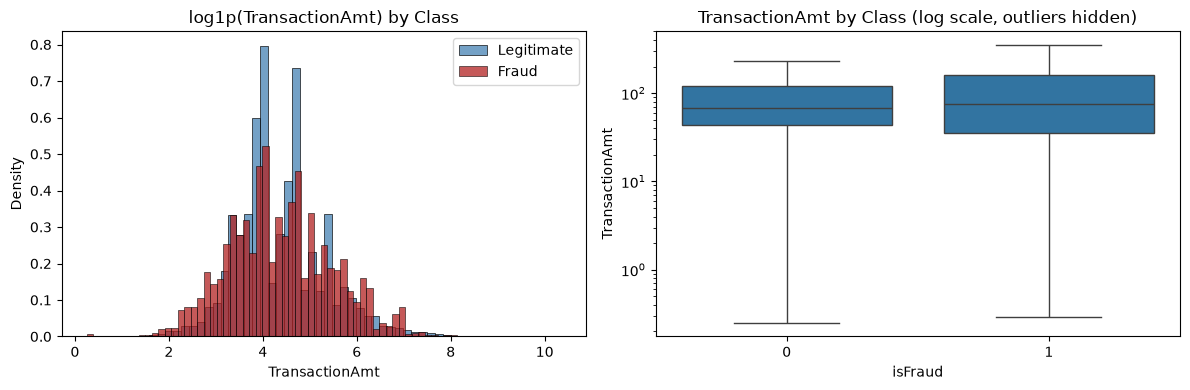

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(np.log1p(train.loc[train["isFraud"] == 0, "TransactionAmt"]),
             bins=60, color="steelblue", label="Legitimate", ax=axes[0], stat="density")
sns.histplot(np.log1p(train.loc[train["isFraud"] == 1, "TransactionAmt"]),
             bins=60, color="firebrick", label="Fraud", ax=axes[0], stat="density")
axes[0].set_title("log1p(TransactionAmt) by Class")
axes[0].legend()

sns.boxplot(x="isFraud", y="TransactionAmt", data=train, ax=axes[1], showfliers=False)
axes[1].set_yscale("log")
axes[1].set_title("TransactionAmt by Class (log scale, outliers hidden)")

plt.tight_layout()
plt.show()


**Hypothesis to carry forward:** note whether fraud transactions skew
toward a different amount range than legitimate ones (higher, lower, or
just wider variance). Whatever the direction, `TransactionAmt` on its own
is a weak signal — it becomes far more useful once compared against an
account's own historical average, which we'll build in
`04_feature_engineering.ipynb`.


## 4. Temporal Behaviour

`TransactionDT` is a time delta (seconds from a fixed reference point,
not a real calendar timestamp), but it still lets us examine daily and
weekly rhythms, and — most importantly — whether the fraud rate itself
shifts over time.


In [14]:
if "TransactionDT" in train.columns:
    seconds_per_day = 24 * 60 * 60
    train["_day"] = (train["TransactionDT"] // seconds_per_day).astype(int)
    train["_hour_of_day"] = (train["TransactionDT"] // 3600) % 24
    train["_day_of_week"] = train["_day"] % 7

    print("Dataset spans", train["_day"].nunique(), "distinct days.")


Dataset spans 182 distinct days.


C:\Users\acer\AppData\Local\Temp\ipykernel_14416\2422196027.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["_day"] = (train["TransactionDT"] // seconds_per_day).astype(int)
C:\Users\acer\AppData\Local\Temp\ipykernel_14416\2422196027.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["_hour_of_day"] = (train["TransactionDT"] // 3600) % 24
C:\Users\acer\AppData\Local\Temp\ipykernel_14416\2422196027.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many

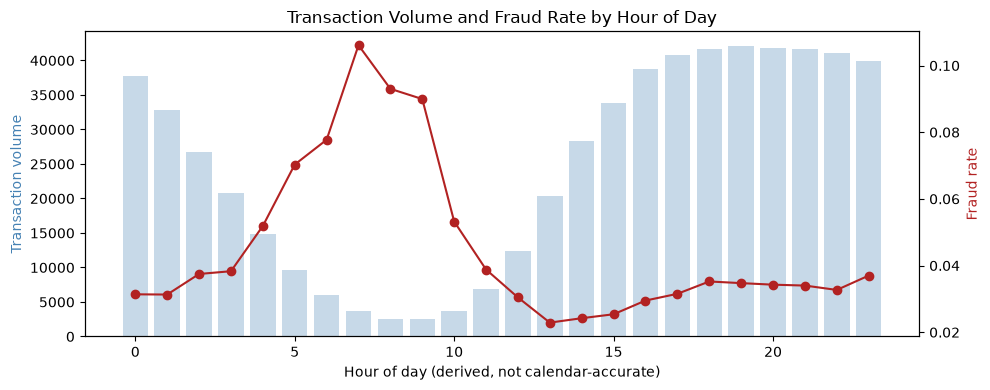

In [15]:
if "TransactionDT" in train.columns:
    hourly_fraud_rate = train.groupby("_hour_of_day")["isFraud"].mean()
    hourly_volume = train.groupby("_hour_of_day").size()

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax2 = ax1.twinx()

    ax1.bar(hourly_volume.index, hourly_volume.values, alpha=0.3, color="steelblue", label="Volume")
    ax2.plot(hourly_fraud_rate.index, hourly_fraud_rate.values, color="firebrick", marker="o", label="Fraud rate")

    ax1.set_xlabel("Hour of day (derived, not calendar-accurate)")
    ax1.set_ylabel("Transaction volume", color="steelblue")
    ax2.set_ylabel("Fraud rate", color="firebrick")
    plt.title("Transaction Volume and Fraud Rate by Hour of Day")
    plt.tight_layout()
    plt.show()


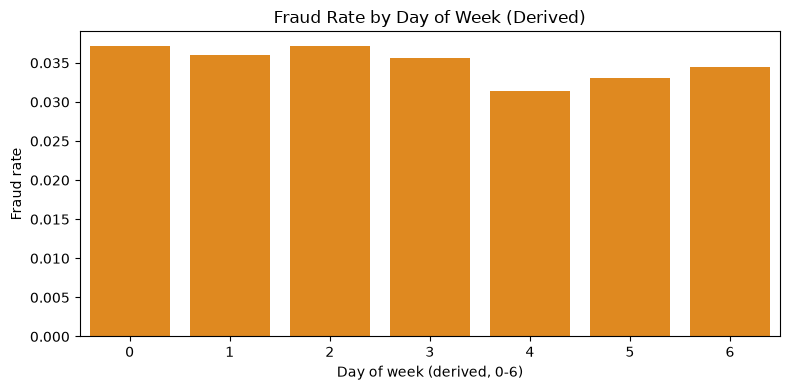

In [16]:
if "TransactionDT" in train.columns:
    dow_fraud_rate = train.groupby("_day_of_week")["isFraud"].mean()

    plt.figure(figsize=(8, 4))
    sns.barplot(x=dow_fraud_rate.index, y=dow_fraud_rate.values, color="darkorange")
    plt.xlabel("Day of week (derived, 0-6)")
    plt.ylabel("Fraud rate")
    plt.title("Fraud Rate by Day of Week (Derived)")
    plt.tight_layout()
    plt.show()


**Hypothesis to carry forward:** if fraud rate is noticeably higher at
certain derived hours (e.g. overnight, when fewer legitimate customers are
shopping but automated fraud scripts don't sleep), `hour_of_day` and
`day_of_week` are strong candidate features. Note we're deriving these
from `TransactionDT`, not a real clock — the *relative* pattern is still
meaningful even though the absolute hour isn't calendar-accurate.


## 5. Categorical Behaviour

For each major categorical field, we look at both its distribution and,
more importantly, how the fraud rate varies across its categories. A
category with very few transactions can show a misleadingly extreme fraud
rate purely by chance, so counts are shown alongside rates.


In [17]:
categorical_cols = [c for c in ["ProductCD", "card4", "card6", "DeviceType",
                                 "P_emaildomain", "R_emaildomain"] if c in train.columns]

for c in categorical_cols:
    summary = train.groupby(c, observed=True).agg(
        count=("isFraud", "size"),
        fraud_rate=("isFraud", "mean")
    ).sort_values("count", ascending=False)
    print(f"--- {c} ---")
    print(summary.head(10).round(4))
    print()


--- ProductCD ---
            count  fraud_rate
ProductCD                    
W          439670      0.0204
C           68519      0.1169
R           37699      0.0378
H           33024      0.0477
S           11628      0.0590

--- card4 ---
                   count  fraud_rate
card4                               
visa              384767      0.0348
mastercard        189217      0.0343
american express    8328      0.0287
discover            6651      0.0773

--- card6 ---
                  count  fraud_rate
card6                              
debit            439938      0.0243
credit           148986      0.0668
debit or credit      30      0.0000
charge card          15      0.0000

--- DeviceType ---
            count  fraud_rate
DeviceType                   
desktop     85165      0.0652
mobile      55645      0.1017

--- P_emaildomain ---
                count  fraud_rate
P_emaildomain                    
gmail.com      228355      0.0435
yahoo.com      100934      0.0228
hotma

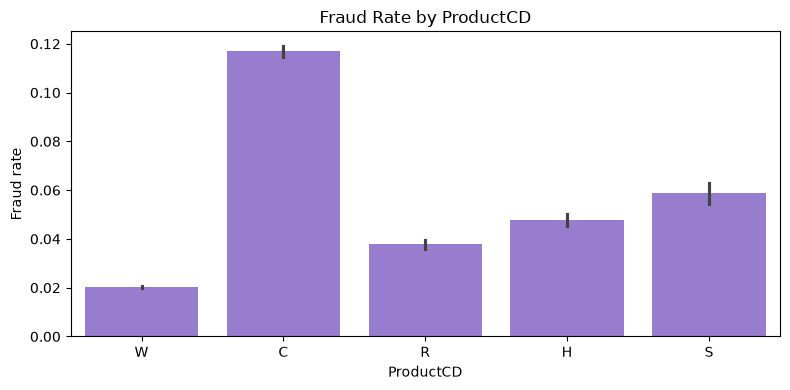

In [18]:
if "ProductCD" in train.columns:
    plt.figure(figsize=(8, 4))
    order = train["ProductCD"].value_counts().index
    sns.barplot(x="ProductCD", y="isFraud", data=train, order=order, color="mediumpurple")
    plt.ylabel("Fraud rate")
    plt.title("Fraud Rate by ProductCD")
    plt.tight_layout()
    plt.show()


**Hypothesis to carry forward:** categories with both meaningful volume and
a fraud rate well above the overall baseline (from section 1) are strong
candidates for one-hot or target encoding. Categories with tiny counts
should not be trusted individually — group rare categories into an
"other" bucket rather than treating each as a separate signal.


## 6. Identity and Device Information

Identity/device fields (`id_01`–`id_38`, `DeviceType`, `DeviceInfo`) are
only present for a minority of transactions, as we already saw in
`02_data_validation.ipynb`. Here we check whether *having* this
information at all relates to fraud, and look at the device fields
themselves where they exist.


In [19]:
id_cols = [c for c in train.columns if c.startswith("id_")]
print(f"Number of id_ columns: {len(id_cols)}")

if id_cols:
    has_identity = train[id_cols].notna().any(axis=1)
    fraud_rate_with_identity = train.loc[has_identity, "isFraud"].mean()
    fraud_rate_without_identity = train.loc[~has_identity, "isFraud"].mean()

    print(f"\n% of transactions with any identity info: {has_identity.mean():.2%}")
    print(f"Fraud rate WITH identity info:    {fraud_rate_with_identity:.4%}")
    print(f"Fraud rate WITHOUT identity info: {fraud_rate_without_identity:.4%}")


Number of id_ columns: 38

% of transactions with any identity info: 24.42%
Fraud rate WITH identity info:    7.8470%
Fraud rate WITHOUT identity info: 2.0939%


In [20]:
if "DeviceType" in train.columns:
    device_summary = train.groupby("DeviceType", observed=True).agg(
        count=("isFraud", "size"),
        fraud_rate=("isFraud", "mean")
    ).sort_values("count", ascending=False)
    print(device_summary.round(4))


            count  fraud_rate
DeviceType                   
desktop     85165      0.0652
mobile      55645      0.1017


**Hypothesis to carry forward:** if the fraud rate differs meaningfully
between "has identity info" and "doesn't," then `has_identity` (a simple
boolean) is worth including as a feature on its own — independent of what
any individual `id_` column contains. This is the same "missingness as
signal" idea from `02_data_validation.ipynb`, applied specifically to the
identity/device block.


## 7. Missingness Patterns

`02_data_validation.ipynb` already quantified missingness column by
column. Here we look at it from an EDA angle: do columns tend to be
missing *together*, in blocks, and does the overall amount of missing
data in a row relate to fraud?


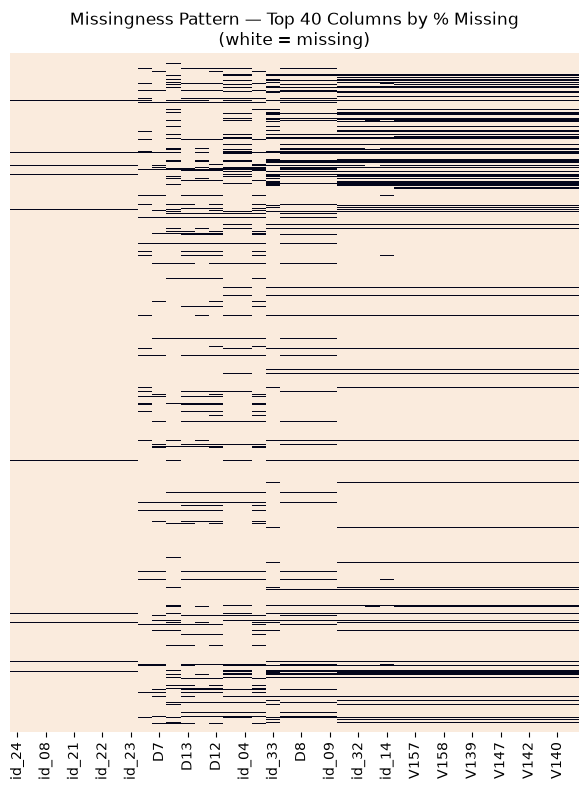

In [21]:
missing_pct = train.isnull().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(6, 8))
sns.heatmap(
    train[missing_pct.head(40).index].isnull(),
    cbar=False,
    yticklabels=False,
)
plt.title("Missingness Pattern — Top 40 Columns by % Missing\n(white = missing)")
plt.tight_layout()
plt.show()


In [22]:
# Does the total number of missing fields in a row relate to fraud?
train["_n_missing"] = train.isnull().sum(axis=1)

missing_vs_fraud = train.groupby(pd.qcut(train["_n_missing"], q=5, duplicates="drop"))["isFraud"].mean()
print("Fraud rate by row-level missingness quintile:")
print(missing_vs_fraud.round(4))


Fraud rate by row-level missingness quintile:
_n_missing
(23.999, 133.0]    0.0816
(133.0, 210.0]     0.0299
(210.0, 213.0]     0.0164
(213.0, 229.0]     0.0237
(229.0, 340.0]     0.0204
Name: isFraud, dtype: float64


C:\Users\acer\AppData\Local\Temp\ipykernel_14416\721837925.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["_n_missing"] = train.isnull().sum(axis=1)


**Hypothesis to carry forward:** if fraud rate rises or falls consistently
across missingness quintiles, `_n_missing` (total missing fields per row)
is itself a candidate feature — a simple, cheap-to-compute summary of how
"thin" a transaction's data profile is.


## 8. Relationships Between Variables and Fraud

Finally, we scan numeric features broadly for association with the
target, without yet committing to any of them as final model inputs. The
goal here is purely to prioritise which features deserve deeper feature
engineering effort.


In [23]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in
                ("isFraud", "_day", "_hour_of_day", "_day_of_week", "_n_missing")]

correlations = train[numeric_cols].corrwith(train["isFraud"]).sort_values(
    key=lambda s: s.abs(), ascending=False
)

print("Top 20 numeric features by absolute correlation with isFraud:")
print(correlations.head(20).round(4))


Top 20 numeric features by absolute correlation with isFraud:
V257    0.3831
V246    0.3669
V244    0.3641
V242    0.3606
V201    0.3280
V200    0.3188
V189    0.3082
V188    0.3036
V258    0.2972
V45     0.2818
V158    0.2781
V156    0.2760
V149    0.2733
V228    0.2689
V44     0.2604
V86     0.2518
V87     0.2517
V170    0.2498
V147    0.2429
V52     0.2395
dtype: float64


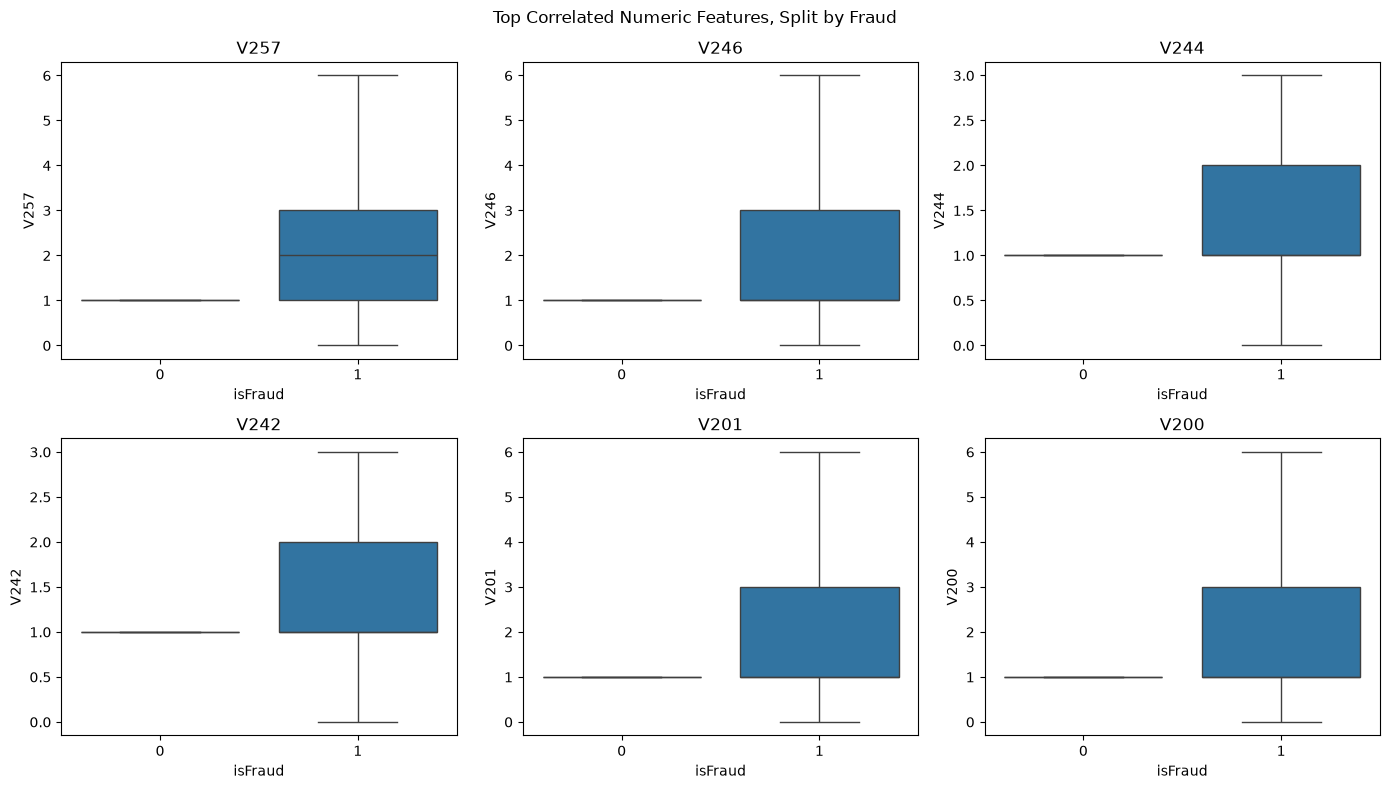

In [24]:
top_features = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.ravel(), top_features):
    sns.boxplot(x="isFraud", y=feat, data=train, ax=ax, showfliers=False)
    ax.set_title(feat)
plt.suptitle("Top Correlated Numeric Features, Split by Fraud")
plt.tight_layout()
plt.show()


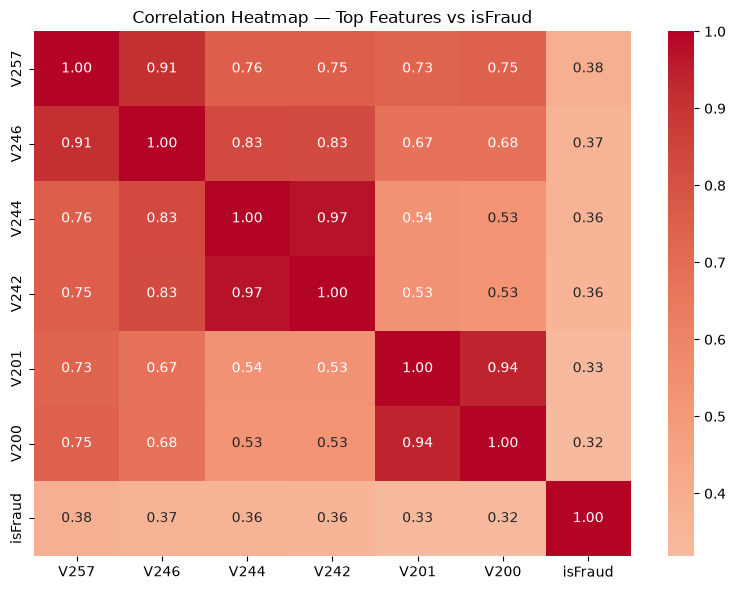

In [25]:
plt.figure(figsize=(8, 6))
corr_matrix = train[top_features + ["isFraud"]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Top Features vs isFraud")
plt.tight_layout()
plt.show()


**Hypothesis to carry forward:** treat this correlation list as a
prioritisation tool, not a final answer. Individually weak correlations
are expected and normal in fraud data (see `15_FEATURE_ENGINEERING`) —
real signal usually emerges from *combinations* of features (e.g. amount
deviation **and** new device **and** unusual hour together), which a
single-variable correlation scan cannot show on its own.


## Summary: Hypotheses Carried Forward to Feature Engineering

This EDA did not select a model or a final feature set. It produced a set
of testable hypotheses to build and check in `04_feature_engineering.ipynb`:

1. Fraud is rare enough that class imbalance must be explicitly handled —
   accuracy is not a usable metric.
2. Most accounts have low transaction volume, so behavioural features may
   need a population-level fallback for thin-history accounts.
3. `TransactionAmt` differs between fraud and legitimate transactions in
   distribution, but is a weak signal on its own — deviation-from-baseline
   features are likely to outperform the raw value.
4. Derived hour-of-day and day-of-week show fraud-rate variation and are
   candidate temporal features.
5. Certain categories in `ProductCD` / device / email-domain fields carry
   above-baseline fraud rates and are candidates for encoding — provided
   they have sufficient volume to trust.
6. Whether identity/device information is present at all (`has_identity`)
   may be as informative as the identity fields' actual values.
7. Row-level missingness count (`_n_missing`) is a candidate cheap summary
   feature.
8. No single numeric feature shows strong standalone correlation with
   fraud — this confirms fraud detection here will depend on combining
   several moderate signals rather than finding one dominant predictor.

**Next step:** `04_feature_engineering.ipynb`, where each hypothesis above
gets turned into an actual, testable feature.
